# Argus Panoptes — XGBoost Baseline Training & Ablations (Day 2)

Explores the DSP-derived feature set in `manifest.parquet`, visualizes
feature↔label correlations, demonstrates tooth-pass-frequency (TPF) tracking with
the `SignalProcessor`, and trains/evaluates the XGBoost baselines + ablations.

Run from the repo root after generating a dataset with features:

```bash
python scripts/generate_dataset.py --num-samples 300 --output-dir data/test_dsp_v1 --extract-features
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "manifest_marker").exists() and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data" / "test_dsp_v1"
df = pd.read_parquet(DATA_DIR / "manifest.parquet")

td = [c for c in df.columns if c.startswith("vib_td_")]
fd = [c for c in df.columns if c.startswith("vib_fd_")]
print(f"rows={len(df)}  time-domain={len(td)}  freq-domain={len(fd)}")
df[td + fd].describe().T.head(12)

rows=300  time-domain=13  freq-domain=15


,count,mean,std,min,25%,50%,75%,max
vib_td_rms,300.0,13.274037,10.689363,0.217379,4.427678,9.849112,20.681337,44.762398
vib_td_peak,300.0,36.069650,24.909952,0.740570,13.924100,29.225141,62.241730,95.553825
vib_td_peak_to_peak,300.0,60.972024,44.130577,1.215610,22.203376,47.821844,98.879049,165.661530
vib_td_crest_factor,300.0,2.936739,0.359298,1.709135,2.805868,3.009675,3.141852,3.781112
vib_td_kurtosis,300.0,-0.488655,0.332219,-1.632287,-0.595915,-0.460062,-0.340694,0.520309
vib_td_skewness,300.0,0.740245,0.137228,0.313351,0.683970,0.756457,0.822344,0.981974
vib_td_shape_factor,300.0,1.206863,0.026368,1.061919,1.196794,1.210252,1.221153,1.319629
vib_td_impulse_factor,300.0,3.551064,0.482312,1.888721,3.391198,3.646993,3.817867,4.769375
vib_td_clearance_factor,300.0,4.030389,0.575203,1.967472,3.858890,4.133501,4.342206,5.762777
vib_td_margin_factor,300.0,0.865633,1.834949,0.043954,0.203660,0.416601,0.968627,22.340776


## 1. Feature ↔ label correlations

Correlation of every DSP feature with the key labels. Amplitude/energy features
(`vib_td_rms`, `vib_fd_tpf_band_energy`, `vib_fd_total_power`) should correlate
positively with `wear_level` / `cycle_time_factor` and negatively with
`quality_score`.

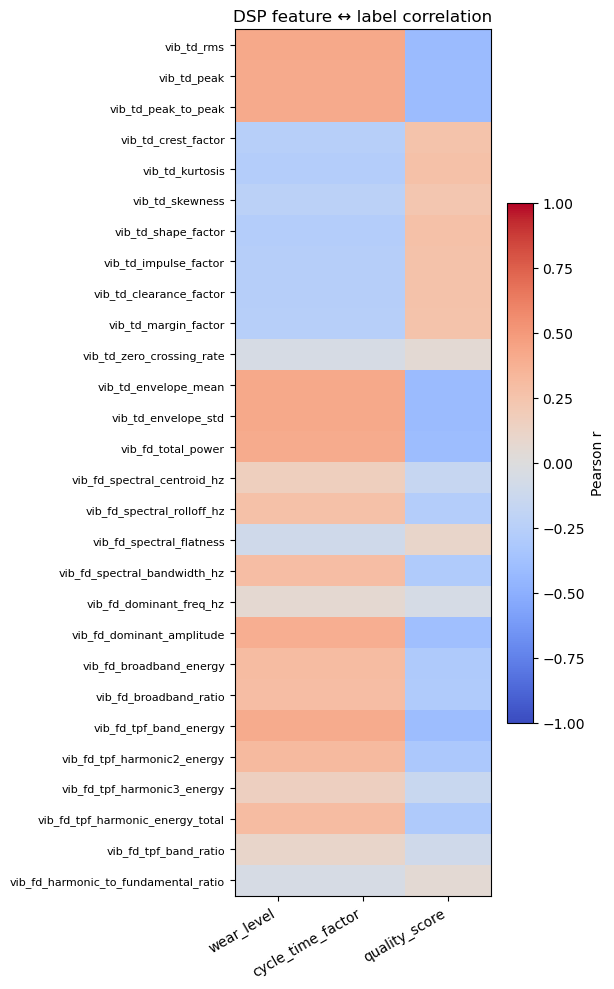

vib_td_rms                   0.419950
vib_td_envelope_mean         0.419744
vib_td_envelope_std          0.415906
vib_td_peak_to_peak          0.411239
vib_td_peak                  0.409598
vib_fd_total_power           0.403804
vib_fd_tpf_band_energy       0.400288
vib_fd_dominant_amplitude    0.388878
Name: label_wear_level, dtype: float64

In [2]:
labels = ["label_wear_level", "label_cycle_time_factor", "label_quality_score"]
feat_cols = td + fd
corr = df[feat_cols + labels].corr().loc[feat_cols, labels]

fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.replace("label_", "") for l in labels], rotation=30, ha="right")
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(feat_cols, fontsize=8)
ax.set_title("DSP feature ↔ label correlation")
fig.colorbar(im, ax=ax, shrink=0.6, label="Pearson r")
fig.tight_layout()
plt.show()

corr["label_wear_level"].abs().sort_values(ascending=False).head(8)

## 2. TPF tracking with the `SignalProcessor`

Run the DSP pipeline directly on fresh simulator output and confirm that the
tooth-pass-band energy climbs with blade wear (impact force ↑).

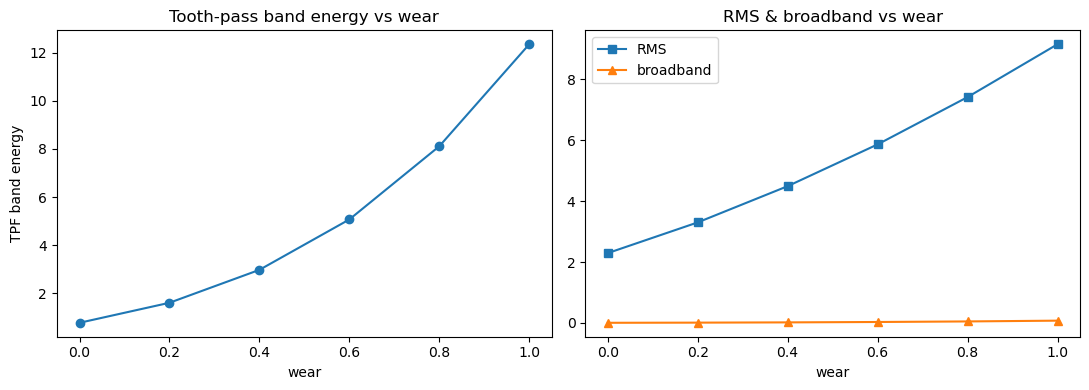

,wear,td_rms,fd_tpf_band_energy,fd_broadband_energy
0,0.0,2.292524,0.775440,0.004709
1,0.2,3.300395,1.607153,0.009871
2,0.4,4.489796,2.974260,0.018290
3,0.6,5.860727,5.067886,0.031070
4,0.8,7.413188,8.108330,0.049483
5,1.0,9.147184,12.345062,0.074971


In [3]:
from sensors import SawVibrationSimulator
from dsp import SignalProcessor

sim = SawVibrationSimulator()
sp = SignalProcessor()

wears = np.linspace(0.0, 1.0, 6)
rows = []
for w in wears:
    _, accel, meta = sim.generate(duration_s=3.0, wear=float(w), seed=7)
    f = sp.process(accel, fs=meta["fs_hz"], metadata=meta)["features"]
    rows.append((w, f["td_rms"], f["fd_tpf_band_energy"], f["fd_broadband_energy"]))

track = pd.DataFrame(rows, columns=["wear", "td_rms", "fd_tpf_band_energy", "fd_broadband_energy"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(track["wear"], track["fd_tpf_band_energy"], "o-")
ax[0].set(xlabel="wear", ylabel="TPF band energy", title="Tooth-pass band energy vs wear")
ax[1].plot(track["wear"], track["td_rms"], "s-", label="RMS")
ax[1].plot(track["wear"], track["fd_broadband_energy"], "^-", label="broadband")
ax[1].set(xlabel="wear", title="RMS & broadband vs wear"); ax[1].legend()
fig.tight_layout(); plt.show()
track

## 3. Train baselines, importances & ablation

Reuse `models.baseline` end-to-end (writes plots to `experiments/plots/`, models
to `experiments/models/`, metrics JSON + `baseline_results.md`). Then render the
importance and ablation tables inline.

In [4]:
from models.baseline import run

report = run(
    data_dir=DATA_DIR,
    models_dir=ROOT / "experiments" / "models",
    plots_dir=ROOT / "experiments" / "plots",
    results_path=ROOT / "experiments" / "baseline_results.md",
    metrics_path=ROOT / "experiments" / "baseline_metrics.json",
    seed=42,
)

# Regression metrics
reg = pd.DataFrame(
    {t: {k: m[k] for k in ("mae", "rmse", "r2")} for t, m in report["regression"].items()}
).T
print("Regression metrics:"); display(reg)

# Ablation table (wear_level)
abl = pd.DataFrame(report["ablation"]["wear_level"]).T[["n_features", "mae", "rmse", "r2", "delta_mae_vs_all"]]
print("Ablation (wear_level):"); display(abl)

# Top-feature importances for the wear model
top = pd.DataFrame(report["regression"]["wear_level"]["top_features"], columns=["feature", "importance"])
top.head(10)

20:30:48 | INFO    | Loaded manifest: 300 rows x 75 cols from C:\Users\logan\Projects\ArgusPanoptes\data\test_dsp_v1\manifest.parquet


20:30:48 | INFO    | Feature groups: time=13 freq=15 thermal=5 context=9 (all=42)


20:30:48 | INFO    | Split: 240 train / 60 test (stratified on wear_bin)


20:30:48 | INFO    | ====================================================================


20:30:48 | INFO    | REGRESSION target: wear_level


...

Regression metrics:


,mae,rmse,r2
wear_level,0.150266,0.186249,0.558021
cycle_time_factor,0.069919,0.086930,0.554706
quality_score,0.074689,0.093195,0.556964


Ablation (wear_level):


,n_features,mae,rmse,r2,delta_mae_vs_all
time_only,13.0,0.243913,0.279330,0.005858,0.093647
freq_only,15.0,0.233357,0.271880,0.058179,0.083091
all,42.0,0.150266,0.186249,0.558021,0.000000


,feature,importance
0,vib_fd_dominant_amplitude,0.330647
1,therm_slope_c_per_s,0.058229
2,max_temp_c,0.049415
3,vib_td_peak_to_peak,0.049311
4,material_removal_rate_mm3_s,0.043032
5,vib_td_margin_factor,0.034476
6,vib_td_envelope_mean,0.032704
7,vib_fd_tpf_harmonic2_energy,0.028697
8,vib_fd_broadband_energy,0.028361
9,vib_fd_tpf_band_energy,0.025594
